**Statistical Tests - Revision**

This script was used in the revision process to compute the statistical tests again while also computing effect size and confidence interval with the Pingouin toolbox.

In [1]:
import pandas as pd
import os
import glob
from pathlib import Path

import numpy as np
from scipy.stats import rankdata, ttest_rel, ttest_1samp,shapiro, levene

from matplotlib import pyplot as plt
import matplotlib.lines as mlines
import matplotlib.transforms as mtransforms

import pandas as pd
import seaborn as sns

In [3]:
import pingouin as pg

**Load in Data**

In [19]:
# Path to Results Folder
folder_path = r"C:\Users\Benutze\Documents\Promotion\Papers\Paper 4\Results\Replication\IS_RSA_values_replication"

# Read in CSV Files
df_nn = pd.read_csv(os.path.join(folder_path, 'IS_RSA_values_all_scenes_nn_replication.csv'))
df_annak = pd.read_csv(os.path.join(folder_path, 'IS_RSA_values_all_scenes_annak_replication.csv'))
df_gauss = pd.read_csv(os.path.join(folder_path, 'IS_RSA_values_all_scenes_gauss_replication.csv'))

# Extract collumns with r_vals
values_nn = df_nn['r_value_nn_all_scenes']
values_annak = df_annak['r_value_annak_all_scenes']
values_gauss = df_gauss ['r_value_gauss_all_scenes']

*Definitions*

In [211]:
def print_ttest_results(res, label="Model"):
    t = res["T"].values[0]
    df = res["dof"].values[0]
    p = res["p_val"].values[0]
    d = res["cohen_d"].values[0]
    ci = res["CI95"].values[0]

    print(f"\n{label}")
    print("-" * len(label))
    print(f"df = {df:.0f}")
    print(f"t  = {t:.3f}")
    print(f"p  = {p:.4g}")
    print(f"d  = {d:.3f}")
    print(f"95% CI = [{ci[0]:.3f}, {ci[1]:.3f}]")

**Statistical Analyses**

**1. Analysis on whole-brain level**

Shapiro-Wilk NN: W = 0.991, p = 0.2267
Normality assumption not violated

Nearest Neighbor Model
----------------------
df = 199
t  = 7.363
p  = 4.655e-12
d  = 0.521
95% CI = [0.010, 0.010]
Shapiro-Wilk AnnaK: W = 0.997, p = 0.9334
Normality assumption not violated

Anna Karenina Model
-------------------
df = 199
t  = -10.678
p  = 2.473e-21
d  = 0.755
95% CI = [-0.060, -0.040]
Shapiro-Wilk Gauss: W = 0.997, p = 0.9765
Normality assumption not violated

Gaussian Model
--------------
df = 199
t  = 5.706
p  = 4.157e-08
d  = 0.403
95% CI = [0.010, 0.020]


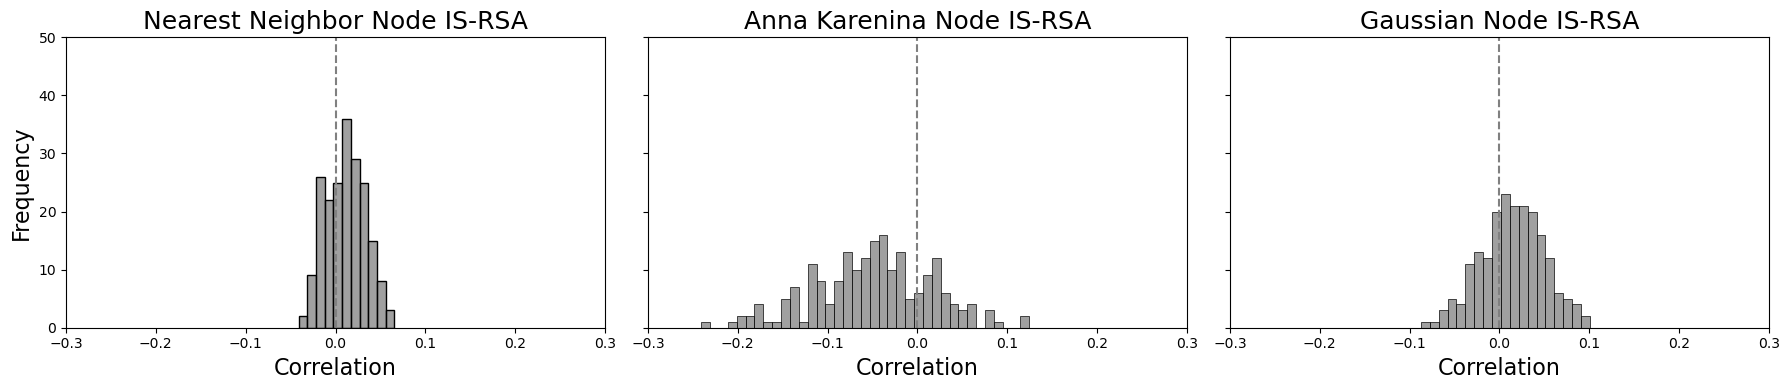

In [213]:
bin_width = 0.01  # Set the same bin width for all plots

f, a = plt.subplots(ncols=3, figsize=(18, 4), sharex=True, sharey=True)

# Nearest Neighbor Model
values_nn = df_nn['r_value_nn_TIR_scenes']
values_nn_z = np.arctanh(values_nn)

shapiro_stat_nn, shapiro_p_nn = shapiro(values_nn_z)
print(f"Shapiro-Wilk NN: W = {shapiro_stat_nn:.3f}, p = {shapiro_p_nn:.4f}")

if shapiro_p_nn < 0.05:
    print("WARNING: Normality assumption violated (p < .05)")
else:
    print("Normality assumption not violated")

res_nn = pg.ttest(values_nn_z,0)
print_ttest_results(res_nn, "Nearest Neighbor Model")

sns.histplot(values_nn_z, ax=a[0], binwidth=bin_width, color = 'gray')
a[0].axvline(0, color='gray', linestyle='--')
a[0].set_xlim(-0.3, 0.3)
a[0].set_ylim(0, 50)
a[0].set_ylabel('Frequency', fontsize=16)
a[0].set_xlabel('Correlation', fontsize=16)
a[0].set_title('Nearest Neighbor Node IS-RSA', fontsize=18)
#a[0].annotate(f't={t_nn:.2f}, p={p_nn:.3f}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=14, color='black')

# Anna Karenina Model
values_annak = df_annak['r_value_annak_TIR_scenes']
values_annak_z = np.arctanh(values_annak)

shapiro_stat_annak, shapiro_p_annak = shapiro(values_annak_z)
print(f"Shapiro-Wilk AnnaK: W = {shapiro_stat_annak:.3f}, p = {shapiro_p_annak:.4f}")

if shapiro_p_annak < 0.05:
    print("WARNING: Normality assumption violated (p < .05)")
else:
    print("Normality assumption not violated")

res_annak = pg.ttest(values_annak_z,0)
print_ttest_results(res_annak, "Anna Karenina Model")

sns.histplot(values_annak_z, ax=a[1], binwidth=bin_width, color = 'gray')
a[1].axvline(0, color='gray', linestyle='--')
a[0].set_xlim(-0.3, 0.3)
a[0].set_ylim(0, 50)
a[1].set_ylabel('Frequency', fontsize=16)
a[1].set_xlabel('Correlation', fontsize=16)
a[1].set_title('Anna Karenina Node IS-RSA', fontsize=18)
# a[1].annotate(f't={t_annak:.2f}, p={p_annak:.3f}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=14, color='black')

# Gaussian Model
values_gauss = df_gauss ['r_value_gauss_TIR_scenes']
values_gauss_z = np.arctanh(values_gauss)

shapiro_stat_gauss, shapiro_p_gauss = shapiro(values_gauss_z)
print(f"Shapiro-Wilk Gauss: W = {shapiro_stat_gauss:.3f}, p = {shapiro_p_gauss:.4f}")

if shapiro_p_gauss < 0.05:
    print("WARNING: Normality assumption violated (p < .05)")
else:
    print("Normality assumption not violated")

res_gauss = pg.ttest(values_gauss_z,0)
print_ttest_results(res_gauss, "Gaussian Model")

sns.histplot(values_gauss_z, ax=a[2], binwidth=bin_width, color = 'gray')
a[2].axvline(0, color='gray', linestyle='--')
a[0].set_xlim(-0.3, 0.3)
a[0].set_ylim(0, 50)
a[2].set_ylabel('Frequency', fontsize=16)
a[2].set_xlabel('Correlation', fontsize=16)
a[2].set_title('Gaussian Node IS-RSA', fontsize=18)
#a[2].annotate(f't={t_gauss:.2f}, p={p_gauss:.3f}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=14, color='black')

plt.tight_layout()


# Save the figure
file_path_figure = r"C:\Users\Benutze\Documents\Promotion\Papers\Paper 4\Results\Figures_Revision\Replication\IS-RSA TIR Scenes\IS_RSA_All_regions_TIR_Scenes_Replication_R1.png"
plt.savefig(file_path_figure, dpi=300, bbox_inches='tight')

plt.show()

Model Comparison 

*Definitions*

In [21]:
def print_anova(table):
    row = table.iloc[0]

    # Original DF
    df1 = row['DF']
    df2 = table.iloc[1]['DF']

    print("\n--- RM-ANOVA ---\n")

    # Always print uncorrected results
    print("Uncorrected:")
    print(
        f"F({df1:.0f}, {df2:.0f}) = "
        f"{row['F']:.3f}, p = {row['p_unc']:.4g}"
    )

    # Effect size
    print(f"generalized η² = {row['ng2']:.3f}")

    # Sphericity information
    if 'p_spher' in row:

        print("\nSphericity Test:")
        print(f"W = {row['W_spher']:.3f}")
        print(f"p = {row['p_spher']:.4g}")
        print(f"epsilon (GG) = {row['eps']:.3f}")
        print(f"Violation = {not row['sphericity']}")

        # If violated → also print corrected results
        if not row['sphericity']:

            gg_df1 = df1 * row['eps']
            gg_df2 = df2 * row['eps']

            print("\nGreenhouse-Geisser corrected:")
            print(
                f"F({gg_df1:.2f}, {gg_df2:.2f}) = "
                f"{row['F']:.3f}, p = {row['p_GG_corr']:.4g}"
            )

In [23]:
def print_posthoc(table):
    print("\n--- POST-HOC COMPARISONS ---\n")
    
    for _, row in table.iterrows():
        
        ci = row.get("CI95%", None)
        
        print(f"{row['A']} vs {row['B']}")
        print(f"t({int(row['dof'])}) = {row['T']:.3f}, p = {row['p_corr']:.4g}")
        print(f"d = {row['cohen']:.3f}")
        
        if ci is not None:
            print(f"95% CI = [{ci[0]:.3f}, {ci[1]:.3f}]")
        
        print("-" * 45)

In [25]:
#Combine Data 
df_combined = df_nn[['node', 'r_value_nn_all_scenes']].merge(
    df_annak[['node', 'r_value_annak_all_scenes']], on='node'
).merge(
    df_gauss[['node', 'r_value_gauss_all_scenes']], on='node'
)

#Convert into long format and Fisher z transformation
df_long = pd.melt(
    df_combined,
    id_vars='node',
    value_vars=[
        'r_value_nn_all_scenes',
        'r_value_annak_all_scenes',
        'r_value_gauss_all_scenes'
    ],
    var_name='condition',
    value_name='r'
)

# Fisher z-transform
df_long["z"] = np.arctanh(df_long["r"])

#ANOVA
aov = pg.rm_anova(
    dv='z',
    within='condition',
    subject='node',
    data=df_long,
    detailed=True
)

print_anova(aov)

#Posthoc

posthoc = pg.pairwise_tests(
    dv='z',
    within='condition',
    subject='node',
    data=df_long,
    padjust='holm',
    effsize='cohen'
)

print_posthoc(posthoc)


--- RM-ANOVA ---

Uncorrected:
F(2, 398) = 250.079, p = 4.567e-71
generalized η² = 0.428

Sphericity Test:
W = 0.105
p = 1.109e-97
epsilon (GG) = 0.528
Violation = True

Greenhouse-Geisser corrected:
F(1.06, 210.01) = 250.079, p = 6.625e-39

--- POST-HOC COMPARISONS ---

r_value_annak_all_scenes vs r_value_gauss_all_scenes
t(199) = -15.090, p = 1.676e-34
d = -1.514
---------------------------------------------
r_value_annak_all_scenes vs r_value_nn_all_scenes
t(199) = -16.934, p = 6.01e-40
d = -1.691
---------------------------------------------
r_value_gauss_all_scenes vs r_value_nn_all_scenes
t(199) = -3.340, p = 0.0009987
d = -0.127
---------------------------------------------


**2. Network-specific analyses**

In [215]:
# Define Nodes belonging to YEO 17 (specific networks)

nodes_yeo_17_network_1_TempPar = [0,1,2,100,101,102,116]
nodes_yeo_17_network_2_DefaultC = [3,4,5,103,104,105]
nodes_yeo_17_network_3_DefaultB = [6,7,8,9,10,11,12,13,14,15,16,17,108,109,111,114,115]
nodes_yeo_17_network_4_DefaultA = [18,19,20,21,22,23,24,25,26,27,107,117,119,120,121,122,123,124,125,126,127]
nodes_yeo_17_network_5_ContC = [28,29,30,128,129,130]
nodes_yeo_17_network_6_ContB = [31,32,33,34,110,118,131,132,133,134]
nodes_yeo_17_network_7_ContA = [35,36,37,38,39,40,41,135,136,137,138,140,141,169]
nodes_yeo_17_network_8_LimbicA = [42,43,142,143]
nodes_yeo_17_network_9_LimbicB = [44,45,46,144,145,146]
nodes_yeo_17_network_10_SalVent_AttnB = [47,48,49,50,106,112,113,139,147,148,149,150]
nodes_yeo_17_network_11_SalVent_AttnA = [51,52,53,54,55,56,151,152,153,154,155,156,178]
nodes_yeo_17_network_12_DorsAttnB = [57,58,59,60,61,62,157,158,159,160,161,162]
nodes_yeo_17_network_13_DorsAttnA = [63,64,65,66,67,68,69,163,164,165,166,167,168]
nodes_yeo_17_network_14_SomMotB = [70,71,72,73,74,75,76,77,78,170,171,172,173,174,175,176,177]
nodes_yeo_17_network_15_SomMotA = [79,80,81,82,83,84,85,86,87,88,179,180,181,182,183,184,185,186,187,188]
nodes_yeo_17_network_16_VisPeri = [89,90,91,92,189,190,191,192]
nodes_yeo_17_network_17_VisCent = [93,94,95,96,97,98,99,193,194,195,196,197,198,199]

In [219]:
# Define nodes belonging to YEO 7 (specific networks) --> According to yeo_17_to_7_matches_with_coords.csv

nodes_yeo_7_network_1_Default = [0,2,3,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,30,33,50,103,105,107,108,109,111,114,115,116,117,118,119,120,121,122,123,124,125,126,127]
nodes_yeo_7_network_2_Cont = [29,31,32,34,35,36,38,39,47,49,106,110,113,128,130,131,132,133,134,136,138,139,147,149,150]
nodes_yeo_7_network_3_Limbic = [42,43,44,45,46,142,143,144,145,146]
nodes_yeo_7_network_4_SalVentAttn = [1,41,48,51,52,53,54,55,56,78,100,101,112,141,148,151,152,153,154,155,156,178]
nodes_yeo_7_network_5_DorsAttn = [37,40,57,58,59,60,61,62,63,64,65,67,68,69,129,135,137,140,157,158,159,160,161,162,163,164,165,166,167,168,169]
nodes_yeo_7_network_6_SomMot = [70,71,72,73,74,75,76,77,79,80,81,82,83,84,85,86,87,88,102,170,171,172,173,174,175,176,177,179,180,181,182,183,184,185,186,187,188]
nodes_yeo_7_network_7_Vis = [4,66,89,90,91,92,93,94,95,96,97,98,99,104,189,190,191,192,193,194,195,196,197,198,199]


In [221]:
network_dict_yeo_17 = {
    "network_1_yeo_17_TempPar": nodes_yeo_17_network_1_TempPar,
    "network_2_yeo_17_DefaultC": nodes_yeo_17_network_2_DefaultC,
    "network_3_yeo_17_DefaultB": nodes_yeo_17_network_3_DefaultB,
    "network_4_yeo_17_DefaultA": nodes_yeo_17_network_4_DefaultA,
    "network_5_yeo_17_ContC": nodes_yeo_17_network_5_ContC,
    "network_6_yeo_17_ContB": nodes_yeo_17_network_6_ContB,
    "network_7_yeo_17_ContA": nodes_yeo_17_network_7_ContA,
    "network_8_yeo_17_LimbicA": nodes_yeo_17_network_8_LimbicA,
    "network_9_yeo_17_LimbicB": nodes_yeo_17_network_9_LimbicB,
    "network_10_yeo_17_SalVentAttnB": nodes_yeo_17_network_10_SalVent_AttnB,
    "network_11_yeo_17_SalVentAttnA": nodes_yeo_17_network_11_SalVent_AttnA,
    "network_12_yeo_17_DorsAttnB": nodes_yeo_17_network_12_DorsAttnB,
    "network_13_yeo_17_DorsAttnA": nodes_yeo_17_network_13_DorsAttnA,
    "network_14_yeo_17_SomMotB": nodes_yeo_17_network_14_SomMotB,
    "network_15_yeo_17_SomMotA": nodes_yeo_17_network_15_SomMotA,
    "network_16_yeo_17_VisPeri": nodes_yeo_17_network_16_VisPeri,
    "network_17_yeo_17_VisCent": nodes_yeo_17_network_17_VisCent,
}

In [223]:
network_dict_yeo_7 = {
    "network_1_yeo_7_Default": nodes_yeo_7_network_1_Default,
    "network_2_yeo_7_Cont": nodes_yeo_7_network_2_Cont,
    "network_3_yeo_7_Limbic": nodes_yeo_7_network_3_Limbic,
    "network_4_yeo_7_SalVentAttn": nodes_yeo_7_network_4_SalVentAttn,
    "network_5_yeo_7_DorsAttn": nodes_yeo_7_network_5_DorsAttn,
    "network_6_yeo_7_SomMot": nodes_yeo_7_network_6_SomMot,
    "network_7_yeo_7_Vis": nodes_yeo_7_network_7_Vis,
}

Shapiro-Wilk NN Network: W = 0.899, p = 0.0175
          W_val alternative     p_val       RBC  CLES
Wilcoxon   70.0   two-sided  0.011453 -0.569231   NaN

Nearest Neighbour Model Network
-------------------------------
df = 24
t  = -2.308
p  = 0.02996
d  = 0.462
95% CI = [-0.020, -0.000]
Shapiro-Wilk AnnaK Network: W = 0.971, p = 0.6666
Normality assumption not violated

Anna Karenina Model Network
---------------------------
df = 24
t  = -8.288
p  = 1.678e-08
d  = 1.658
95% CI = [-0.080, -0.050]
Shapiro-Wilk Gauss Network: W = 0.925, p = 0.0654
Normality assumption not violated

Gaussian Model Network
----------------------
df = 24
t  = -2.507
p  = 0.01937
d  = 0.501
95% CI = [-0.030, -0.000]


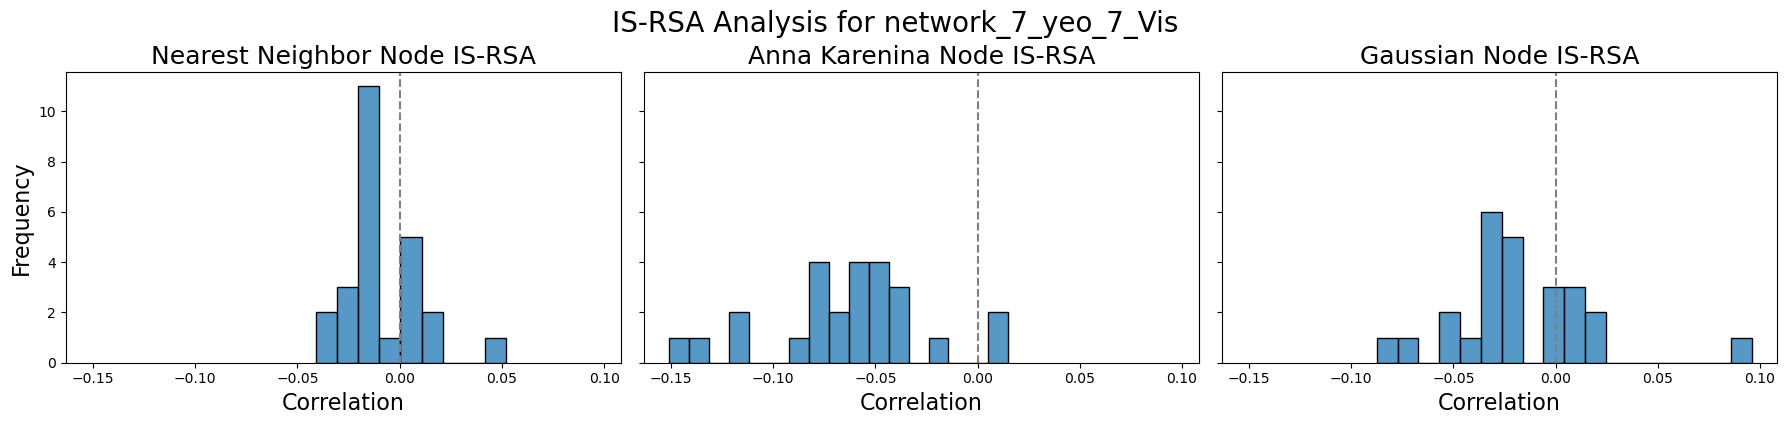

In [237]:
# Extract values for the selected nodes

network_name = "network_7_yeo_7_Vis" #Change Network Name (from dictionary) here!

nodes_belonging_to_network = network_dict_yeo_7[network_name]

values_network_nn = values_nn_z.iloc[nodes_belonging_to_network]
values_network_annak = values_annak_z.iloc[nodes_belonging_to_network]
values_network_gauss = values_gauss_z.iloc[nodes_belonging_to_network]

bin_width = 0.01  # Set the same bin width for all plots

f, a = plt.subplots(ncols=3, figsize=(18, 4), sharex=True, sharey=True)

# Nearest Neighbor Model
shapiro_stat_nn_network, shapiro_p_nn_network = shapiro(values_network_nn)
print(f"Shapiro-Wilk NN Network: W = {shapiro_stat_nn_network:.3f}, p = {shapiro_p_nn_network:.4f}")

if shapiro_p_nn_network < 0.05:
    print("WARNING: Normality assumption violated (p < .05)")
else:
    print("Normality assumption not violated")

if shapiro_p_nn_network < 0.05:
    res_nn_network_w = pg.wilcoxon(values_network_nn)
    print(res_nn_network_w)
    res_nn_network = pg.ttest(values_network_nn,0)
    print_ttest_results(res_nn_network, "Nearest Neighbour Model Network")
else:
    res_nn_network = pg.ttest(values_network_nn,0)
    print_ttest_results(res_nn_network, "Nearest Neighbour Model Network")

sns.histplot(values_network_nn, ax=a[0], binwidth=bin_width)
a[0].axvline(0, color='gray', linestyle='--')
a[0].set_ylabel('Frequency', fontsize=16)
a[0].set_xlabel('Correlation', fontsize=16)
a[0].set_title('Nearest Neighbor Node IS-RSA', fontsize=18)
#a[0].annotate(f't={t_nn:.2f}, p={p_nn:.3f}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=14, color='black')

# Anna Karenina Model
shapiro_stat_annak_network, shapiro_p_annak_network = shapiro(values_network_annak)
print(f"Shapiro-Wilk AnnaK Network: W = {shapiro_stat_annak_network:.3f}, p = {shapiro_p_annak_network:.4f}")

if shapiro_p_annak_network < 0.05:
    print("WARNING: Normality assumption violated (p < .05)")
else:
    print("Normality assumption not violated")

if shapiro_p_annak_network < 0.05:
    res_annak_network_w = pg.wilcoxon(values_network_annak)
    print(res_annak_network_w)
    res_annak_network = pg.ttest(values_network_annak,0)
    print_ttest_results(res_annak_network, "Anna Karenina Model Network")
else:
    res_annak_network = pg.ttest(values_network_annak,0)
    print_ttest_results(res_annak_network, "Anna Karenina Model Network")

sns.histplot(values_network_annak, ax=a[1], binwidth=bin_width)
a[1].axvline(0, color='gray', linestyle='--')
a[1].set_ylabel('Frequency', fontsize=16)
a[1].set_xlabel('Correlation', fontsize=16)
a[1].set_title('Anna Karenina Node IS-RSA', fontsize=18)
#a[1].annotate(f't={t_annak:.2f}, p={p_annak:.3f}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=14, color='black')

# Gaussian Model
shapiro_stat_gauss_network, shapiro_p_gauss_network = shapiro(values_network_gauss)
print(f"Shapiro-Wilk Gauss Network: W = {shapiro_stat_gauss_network:.3f}, p = {shapiro_p_gauss_network:.4f}")

if shapiro_p_gauss_network < 0.05:
    print("WARNING: Normality assumption violated (p < .05)")
else:
    print("Normality assumption not violated")

if shapiro_p_gauss_network < 0.05:
    res_gauss_network_w = pg.wilcoxon(values_network_gauss)
    print(res_gauss_network_w)
    res_gauss_network = pg.ttest(values_network_gauss,0)
    print_ttest_results(res_gauss_network, "Gaussian Model Network")
else:
    res_gauss_network = pg.ttest(values_network_gauss,0)
    print_ttest_results(res_gauss_network, "Gaussian Model Network")

sns.histplot(values_network_gauss, ax=a[2], binwidth=bin_width)
a[2].axvline(0, color='gray', linestyle='--')
a[2].set_ylabel('Frequency', fontsize=16)
a[2].set_xlabel('Correlation', fontsize=16)
a[2].set_title('Gaussian Node IS-RSA', fontsize=18)
#a[2].annotate(f't={t_gauss:.2f}, p={p_gauss:.3f}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=14, color='black')

plt.tight_layout()

plt.suptitle(f"IS-RSA Analysis for {network_name}", fontsize=20, y=1.05)

# Save the figure
file_path_figure = r"C:\Users\Benutze\Documents\Promotion\Papers\Paper 4\Results\Figures_Revision\Replication\IS-RSA TIR Scenes\Network_specific_analyses\Yeo_7"
plt.savefig(f"{file_path_figure}/IS_RSA_{network_name}_TIR_Scenes_replication.png", dpi=300, bbox_inches='tight')

plt.show()

**3. T-Test IS-RSA values between trair-relevant and trait-irrelevant Scenes**

In [239]:
# Load in Data 
path = r"C:\Users\Benutze\Documents\Promotion\Papers\Paper 4\Results\Replication\IS_RSA_values_replication"
tr_df = pd.read_csv(f"{path}\\IS_RSA_values_TR_scenes_annak_replication.csv")
tir_df = pd.read_csv(f"{path}\\IS_RSA_values_TIR_scenes_annak_replication.csv")

# Extract columns with r_vals and convert into z-scores
tr_values = tr_df['r_value_annak_TR_scenes']
tr_values_z = np.arctanh(tr_values)

tir_values = tir_df['r_value_annak_TIR_scenes']
tir_values_z = np.arctanh(tir_values)

*Definition of Functions*

In [241]:
# Print results from paired t-test
def print_paired_results(res, label):
    
    t = res['T'].values[0]
    df = res['dof'].values[0]
    p = res['p_val'].values[0]
    d = res['cohen_d'].values[0]
    ci = res['CI95'].values[0]

    print(f"\n{label}")
    print("-" * len(label))
    print(f"t({df:.0f}) = {t:.3f}")
    print(f"p = {p:.4g}")
    print(f"Cohen's d = {d:.3f}")
    print(f"95% CI = [{ci[0]:.3f}, {ci[1]:.3f}]")

In [243]:
# Check assumptions for 2-sided t-test 

def check_assumptions(x, y, label):

    print(f"\n--- ASSUMPTION CHECKS: {label} ---")

    # 1. Normality of difference scores

    diff = x - y

    shapiro_stat, shapiro_p = shapiro(diff)

    print(f"Shapiro-Wilk on difference scores:")
    print(f"W = {shapiro_stat:.3f}, p = {shapiro_p:.4f}")

    if shapiro_p < 0.05:
        print("⚠️ Normality assumption violated")
    else:
        print("✅ Normality assumption not violated")

    # 2. Homogeneity of variance

    lev_stat, lev_p = levene(x, y)

    print(f"\nLevene test:")
    print(f"W = {lev_stat:.3f}, p = {lev_p:.4f}")

    if lev_p < 0.05:
        print("⚠️ Variances differ")
    else:
        print("✅ Similar variances")

    return shapiro_p

In [245]:
# Function to actually run the t-test

def run_paired_analysis(x, y, label):

    shapiro_p = check_assumptions(x, y, label)

    # if assumptions ok --> run paired t-test

    if shapiro_p >= 0.05:

        print("\nRunning paired-sample t-test...")

        res = pg.ttest(
            x,
            y,
            paired=True
        )

        print_paired_results(res, label)

    # if assumption is violated run Wilcoxon

    else:

        print("\nRunning Wilcoxon signed-rank test...")

        res = pg.wilcoxon(x, y)

        print(res)

*Analysis *

In [247]:
# 1. All Nodes 

run_paired_analysis(
    tr_values_z,
    tir_values_z,
    "ALL NODES"
)


# 2. Network-specific Analyses
networks = {
    "Default": [0,2,3,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,30,33,50,103,105,107,108,109,111,114,115,116,117,118,119,120,121,122,123,124,125,126,127],

    "Cont": [29,31,32,34,35,36,38,39,47,49,106,110,113,128,130,131,132,133,134,136,138,139,147,149,150],

    "Limbic": [42,43,44,45,46,142,143,144,145,146],

    "SalVentAttn": [1,41,48,51,52,53,54,55,56,78,100,101,112,141,148,151,152,153,154,155,156,178],

    "DorsAttn": [37,40,57,58,59,60,61,62,63,64,65,67,68,69,129,135,137,140,157,158,159,160,161,162,163,164,165,166,167,168,169],

    "SomMot": [70,71,72,73,74,75,76,77,79,80,81,82,83,84,85,86,87,88,102,170,171,172,173,174,175,176,177,179,180,181,182,183,184,185,186,187,188],

    "Vis": [4,66,89,90,91,92,93,94,95,96,97,98,99,104,189,190,191,192,193,194,195,196,197,198,199]
}

print("\n\n==============================")
print("NETWORK-SPECIFIC COMPARISONS")
print("==============================")

for name, indices in networks.items():

    tr_net = tr_values_z.iloc[indices]
    tir_net = tir_values_z.iloc[indices]

    run_paired_analysis(
        tr_net,
        tir_net,
        name
    )


--- ASSUMPTION CHECKS: ALL NODES ---
Shapiro-Wilk on difference scores:
W = 0.989, p = 0.1326
✅ Normality assumption not violated

Levene test:
W = 0.002, p = 0.9639
✅ Similar variances

Running paired-sample t-test...

ALL NODES
---------
t(199) = -7.665
p = 7.729e-13
Cohen's d = 0.463
95% CI = [-0.040, -0.020]


NETWORK-SPECIFIC COMPARISONS

--- ASSUMPTION CHECKS: Default ---
Shapiro-Wilk on difference scores:
W = 0.983, p = 0.6768
✅ Normality assumption not violated

Levene test:
W = 1.427, p = 0.2352
✅ Similar variances

Running paired-sample t-test...

Default
-------
t(49) = -4.686
p = 2.248e-05
Cohen's d = 0.614
95% CI = [-0.050, -0.020]

--- ASSUMPTION CHECKS: Cont ---
Shapiro-Wilk on difference scores:
W = 0.908, p = 0.0278
⚠️ Normality assumption violated

Levene test:
W = 0.325, p = 0.5716
✅ Similar variances

Running Wilcoxon signed-rank test...
          W_val alternative     p_val       RBC    CLES
Wilcoxon   81.0   two-sided  0.027479 -0.501538  0.3472

--- ASSUMPTION C